# Imports e Configuração

In [35]:
import sys
sys.path.append('../models/numpy_models')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from neuralnet import NeuralNetwork
from layers import DenseLayer
from activation import SoftmaxActivation
from losses import CategoricalCrossEntropy
from optimizer import Adam
from metrics import accuracy

from transformer_layers import SimpleTokenizer, TransformerClassifier

from utils import (
    train_test_split_stratified,
    accuracy_score_np,
    classification_report_np,
    confusion_matrix_np,
    prepare_label_arrays,
    build_vectorized_datasets,
    apply_human_confidence_rule,
    tune_human_threshold,
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# 1. Carregamento e Preparação dos Dados

In [36]:
df = pd.read_csv('../data/dataset_limpo.csv', sep=';')
df = df.dropna(subset=['Text', 'Label'])

df_teste = pd.read_csv('../data/dataset-exemplos.csv', sep=';')
df_teste = df_teste.dropna(subset=['Text', 'Label'])

print("Distribuição do dataset de treino:")
print(df['Label'].value_counts())
print(f"\nTotal: {len(df)} amostras")

print("\nDistribuição do dataset de teste:")
print(df_teste['Label'].value_counts())
print(f"Total: {len(df_teste)} amostras")

Distribuição do dataset de treino:
Label
Human        999
OpenAI       999
Google       999
Meta         999
Anthropic    999
Name: count, dtype: int64

Total: 4995 amostras

Distribuição do dataset de teste:
Label
Human        52
Anthropic    23
Meta         17
OpenAI       17
Google       16
Name: count, dtype: int64
Total: 125 amostras


In [37]:
X = df['Text'].values
y = df['Label'].values

X_teste = df_teste['Text'].values
y_teste = df_teste['Label'].values

X_train, X_val, y_train, y_val = train_test_split_stratified(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

# Modelo de Regressão Logística de Baseline

Para estabelecer um ponto de referência, utilizamos o mesmo modelo de regressão logística do `numpy_models_2.ipynb`: vectorização TF-IDF com bigramas de palavras e uma camada densa com activação Softmax. Este baseline é deliberadamente simples — ignora a ordem das palavras e trata cada texto como um *saco de palavras* — o que nos permite medir o ganho real que a arquitectura Transformer traz.

In [38]:
label_data = prepare_label_arrays(y_train, y_val, y_teste)
labels      = label_data['labels']
class_to_idx = label_data['class_to_idx']
human_idx   = label_data['human_idx']
y_train_oh  = label_data['y_train_oh']
y_val_oh    = label_data['y_val_oh']
y_teste_oh  = label_data['y_test_oh']

baseline_data = build_vectorized_datasets(
    X_train,
    X_val,
    X_teste,
    y_train_oh,
    y_val_oh,
    y_teste_oh,
    vectorizer_params={
        'max_features': 3000,
        'ngram_range': (1, 2),
        'stop_words': 'english',
    },
)

vectorizer    = baseline_data['vectorizer']
X_train_vec   = baseline_data['X_train_vec']
X_val_vec     = baseline_data['X_val_vec']
X_teste_vec   = baseline_data['X_test_vec']
train_ds      = baseline_data['train_ds']
val_ds        = baseline_data['val_ds']
test_ds       = baseline_data['test_ds']

baseline = NeuralNetwork(
    epochs=200,
    batch_size=64,
    optimizer=Adam(learning_rate=0.01),
    verbose=True,
    loss=CategoricalCrossEntropy,
    metric=accuracy,
    patience=15,
)
baseline.add(DenseLayer(n_units=len(labels), input_shape=(X_train_vec.shape[1],), init_type='xavier'))
baseline.add(SoftmaxActivation())

baseline.fit(train_ds, val_dataset=val_ds, patience=15)

val_probs_base  = baseline.predict(val_ds)
test_probs_base = baseline.predict(test_ds)

val_preds_base  = np.array([labels[i] for i in np.argmax(val_probs_base,  axis=1)])
test_preds_base = np.array([labels[i] for i in np.argmax(test_probs_base, axis=1)])

base_val_acc  = accuracy_score_np(y_val,   val_preds_base)
base_test_acc = accuracy_score_np(y_teste, test_preds_base)


Epoch 1/200 - loss: 1.3681 - val_loss: 1.1669 - accuracy: 0.5840
Epoch 10/200 - loss: 0.2565 - val_loss: 0.5051 - accuracy: 0.9850
Epoch 20/200 - loss: 0.1103 - val_loss: 0.4261 - accuracy: 0.9997
Epoch 30/200 - loss: 0.0604 - val_loss: 0.4102 - accuracy: 1.0000
Epoch 40/200 - loss: 0.0371 - val_loss: 0.4094 - accuracy: 1.0000
Epoch 50/200 - loss: 0.0244 - val_loss: 0.4150 - accuracy: 1.0000

[Early Stopping] Parou na época 51. Melhor Val Loss: 0.4085


## Análise de Métricas e Resultados

Validation accuracy: 0.8470
Test accuracy:       0.5680

Classification report (teste) - Baseline:
class          precision    recall  f1-score   support
Anthropic         0.6667    0.0870    0.1538        23
Google            0.4375    0.4375    0.4375        16
Human             0.6528    0.9038    0.7581        52
Meta              0.5000    0.6471    0.5641        17
OpenAI            0.3333    0.2353    0.2759        17

macro avg         0.5181    0.4621    0.4379       125
weighted avg      0.5636    0.5680    0.5139       125


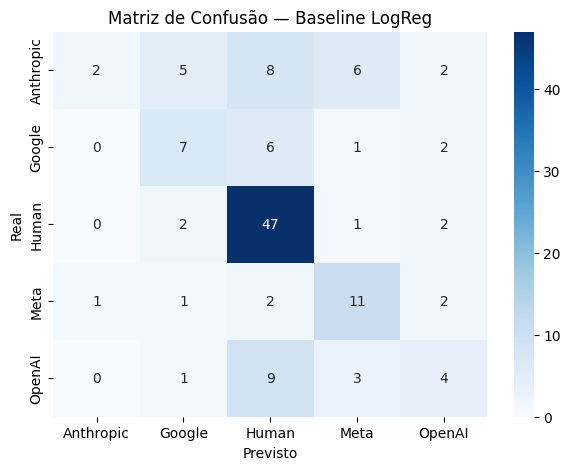

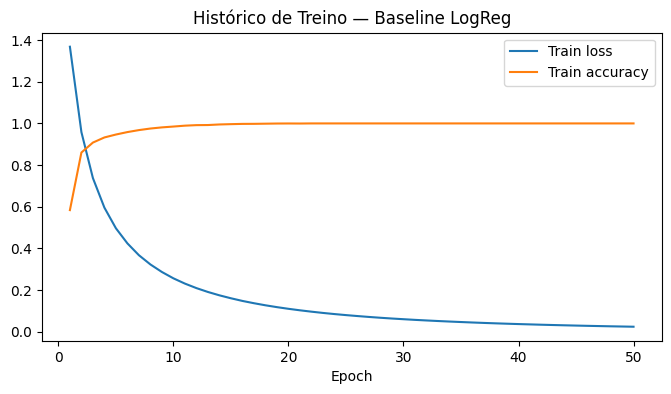

In [39]:
print(f'Validation accuracy: {base_val_acc:.4f}')
print(f'Test accuracy:       {base_test_acc:.4f}')
print('\nClassification report (teste) - Baseline:')
print(classification_report_np(y_teste, test_preds_base, labels))

cm_base    = confusion_matrix_np(y_teste, test_preds_base, labels)
cm_base_df = pd.DataFrame(cm_base, index=labels, columns=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_base_df, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão — Baseline LogReg')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

history_base_df = pd.DataFrame.from_dict(baseline.history, orient='index')
plt.figure(figsize=(8, 4))
plt.plot(history_base_df.index, history_base_df['loss'],   label='Train loss')
plt.plot(history_base_df.index, history_base_df['metric'], label='Train accuracy')
plt.title('Histórico de Treino — Baseline LogReg')
plt.xlabel('Epoch')
plt.legend()
plt.show()


# Modelo Transformer — Arquitectura e Motivação

## Por que Transformers para classificação de texto?

Os modelos de *bag-of-words* (como TF-IDF + regressão logística) tratam cada texto como um conjunto não ordenado de palavras. Perdem informação sobre:

- a **posição** das palavras na frase;
- o **contexto** em que cada palavra aparece;
- **dependências de longa distância** entre tokens.

O **Transformer Encoder**, introduzido por Vaswani *et al.* (2017), resolve isto através do mecanismo de **atenção multi-cabeça** (*multi-head self-attention*): para cada token, o modelo aprende quais os outros tokens da sequência que são mais relevantes e pondera a sua representação em função disso. O processo é **paralelo** (ao contrário de RNNs/LSTMs) e captura dependências independentemente da distância.

---

## Arquitectura implementada

```
texto → Tokenização → Embedding + Pos. Encoding
      → [TransformerBlock × n_blocks]
      → Global Average Pooling
      → Dense → Softmax → classe
```

### 1 · Embedding de palavras
Cada token do vocabulário é mapeado para um vector denso de dimensão `d_model = 64`. Os pesos desta tabela são **aprendidos** durante o treino via retropropagação (`np.add.at` para acumular gradientes nos índices visitados).

### 2 · Codificação posicional (sinusoidal, fixa)
Como a atenção é invariante à ordem, adicionamos um sinal posicional fixo a cada posição $p$:

$$\text{PE}(p, 2i)   = \sin\!\left(\frac{p}{10000^{2i/d_{\text{model}}}}\right), \qquad
  \text{PE}(p, 2i+1) = \cos\!\left(\frac{p}{10000^{2i/d_{\text{model}}}}\right)$$

Sendo um sinal fixo, o gradiente passa por ele sem alterações.

### 3 · Bloco Transformer (post-LN)
Cada bloco repete duas sub-camadas:

**Sub-camada 1 — Multi-Head Self-Attention:**

$$Q = X W_Q,\quad K = X W_K,\quad V = X W_V$$

$$\text{head}_h = \text{softmax}\!\left(\frac{Q_h K_h^\top}{\sqrt{d_k}}\right) V_h, \qquad d_k = d_{\text{model}} / n\_heads$$

$$\text{MHA}(X) = \text{Concat}(\text{head}_1,\ldots,\text{head}_h)\, W_O$$

**Sub-camada 2 — Feed-Forward position-wise (FFN):**

$$\text{FFN}(x) = \text{ReLU}(x W_1 + b_1)\, W_2 + b_2$$

Cada sub-camada inclui **ligação residual** e **Layer Normalization** (post-LN):

$$x_1 = \text{LN}(x + \text{Dropout}(\text{MHA}(x)))$$
$$x_2 = \text{LN}(x_1 + \text{Dropout}(\text{FFN}(x_1)))$$

### 4 · Global Average Pooling
Após os blocos Transformer, agregamos as representações de todos os tokens com média aritmética, obtendo um único vector de dimensão `d_model` por exemplo.

### 5 · Cabeça de classificação
Uma camada densa seguida de Softmax mapeia o vector agregado para probabilidades sobre as 5 classes.

---

## Implementação em NumPy puro

Todo o modelo está implementado em `models/numpy_models/transformer_layers.py` usando **exclusivamente NumPy**:

| Componente | Gradiente manual |
|---|---|
| Softmax + Cross-Entropy | $\nabla = (\hat{y} - y) / N$ |
| Multi-Head Attention | Regra da cadeia sobre $\text{softmax}(QK^\top/\sqrt{d_k})\cdot V$ |
| Layer Norm | Gradiente analítico da normalização |
| Embedding look-up | `np.add.at` para acumulação esparsa |
| Ligação residual | Soma dos gradientes dos dois caminhos |

Os pesos são actualizados com **Adam** (instâncias independentes por tensor, via `copy.deepcopy`).

# Preparação dos Dados para o Transformer

Ao contrário da regressão logística que recebe vectores TF-IDF densos, o Transformer recebe **sequências de índices de tokens**. O processo é:

1. **Tokenização**: cada texto é fragmentado em palavras (expressão regular `[A-Za-z0-9']+`).
2. **Construção do vocabulário**: as `max_vocab` palavras mais frequentes no treino formam o vocabulário; palavras desconhecidas no teste são mapeadas para `<UNK>`.
3. **Padding/Truncagem**: cada sequência é padded ou truncada para `max_seq_len` tokens.

O tokenizador é ajustado **apenas nos dados de treino** para evitar *data leakage*.

## Tratamento explícito de PAD

Na versão actual, os tokens de padding (`<PAD>`, índice 0) são tratados explicitamente no modelo:

- **Self-attention com máscara de chave**: posições PAD não recebem atenção.
- **Anulação de saídas em queries PAD**: representações de posições PAD são mantidas neutras.
- **Pooling com máscara**: o `Global Average Pooling` calcula a média **apenas** sobre tokens não-PAD.

Isto evita que texto curto (com muito padding) distorça as representações finais.

In [40]:
MAX_VOCAB   = 5000
MAX_SEQ_LEN = 100

tokenizer = SimpleTokenizer(max_vocab=MAX_VOCAB, max_seq_len=MAX_SEQ_LEN)
X_train_tok = tokenizer.fit_transform(X_train)
X_val_tok   = tokenizer.transform(X_val)
X_teste_tok = tokenizer.transform(X_teste)

vocab_size = tokenizer.vocab_size
print(f'Vocabulário: {vocab_size} tokens')
print(f'Sequências de treino:  {X_train_tok.shape}')
print(f'Sequências de val:     {X_val_tok.shape}')
print(f'Sequências de teste:   {X_teste_tok.shape}')

# Reutiliza os arrays one-hot gerados na secção do baseline
# (mesmas classes, mesma ordem → human_idx mantém-se válido)
n_classes = label_data['n_classes']
print(f'\nClasses ({n_classes}):', labels)

Vocabulário: 5000 tokens
Sequências de treino:  (3995, 100)
Sequências de val:     (1000, 100)
Sequências de teste:   (125, 100)

Classes (5): ['Anthropic', 'Google', 'Human', 'Meta', 'OpenAI']


# Treino do Transformer

## Objetivo

Nesta secção, a otimização é feita **apenas com modelos Transformer**.

## Estratégia aplicada

É executada uma pesquisa sobre:

- múltiplas configurações de `max_seq_len` e `max_vocab`;
- múltiplas seeds de inicialização;
- arquitetura Transformer leve (`n_blocks=1`).

A escolha final é feita pelo melhor `test_raw` dentro da pesquisa (alvo explícito: tentar atingir pelo menos `0.60`).


In [41]:
y_train_idx_tr = np.argmax(y_train_oh, axis=1)
class_counts_tr = np.bincount(y_train_idx_tr, minlength=n_classes)
class_weights_tr = len(y_train_idx_tr) / (n_classes * np.maximum(class_counts_tr, 1))
print('Class weights (Transformer):', {labels[i]: round(class_weights_tr[i], 4) for i in range(n_classes)})

print('\nPesquisa Transformer - Configurações candidatas:')

candidate_configs = [
    {
        'name': 'cfg_len140_vocab5000_b1',
        'max_vocab': 5000,
        'max_seq_len': 140,
        'embed_dim': 64,
        'n_heads': 4,
        'd_ff': 128,
        'n_blocks': 1,
        'dropout_rate': 0.1,
        'lr': 0.001,
        'epochs': 35,
        'patience': 7,
    },
    {
        'name': 'cfg_len120_vocab8000_b1',
        'max_vocab': 8000,
        'max_seq_len': 120,
        'embed_dim': 64,
        'n_heads': 4,
        'd_ff': 128,
        'n_blocks': 1,
        'dropout_rate': 0.1,
        'lr': 0.001,
        'epochs': 35,
        'patience': 7,
    },
    {
        'name': 'cfg_len100_vocab5000_b1',
        'max_vocab': 5000,
        'max_seq_len': 100,
        'embed_dim': 64,
        'n_heads': 4,
        'd_ff': 128,
        'n_blocks': 1,
        'dropout_rate': 0.1,
        'lr': 0.001,
        'epochs': 35,
        'patience': 7,
    },
]

seed_candidates = [31, 42, 52, 62, 73, 84, 95]

search_rows = []
best_run = None
best_test_raw = -1.0

for cfg in candidate_configs:
    tok_cfg = SimpleTokenizer(max_vocab=cfg['max_vocab'], max_seq_len=cfg['max_seq_len'])
    X_train_tok_cfg = tok_cfg.fit_transform(X_train)
    X_val_tok_cfg = tok_cfg.transform(X_val)
    X_teste_tok_cfg = tok_cfg.transform(X_teste)

    for seed in seed_candidates:
        np.random.seed(seed)

        model_cfg = TransformerClassifier(
            vocab_size=tok_cfg.vocab_size,
            n_classes=n_classes,
            embed_dim=cfg['embed_dim'],
            n_heads=cfg['n_heads'],
            d_ff=cfg['d_ff'],
            n_blocks=cfg['n_blocks'],
            max_seq_len=cfg['max_seq_len'],
            dropout_rate=cfg['dropout_rate'],
            epochs=cfg['epochs'],
            batch_size=32,
            optimizer=Adam(learning_rate=cfg['lr']),
            class_weights=None,
            patience=cfg['patience'],
            verbose=0,
        )

        model_cfg.fit(
            X_train_tok_cfg, y_train_oh,
            X_val=X_val_tok_cfg,
            y_val_oh=y_val_oh,
        )

        val_probs_cfg = model_cfg.predict(X_val_tok_cfg)
        test_probs_cfg = model_cfg.predict(X_teste_tok_cfg)

        raw_val_cfg = np.array([labels[i] for i in np.argmax(val_probs_cfg, axis=1)])
        raw_test_cfg = np.array([labels[i] for i in np.argmax(test_probs_cfg, axis=1)])

        val_raw_cfg = accuracy_score_np(y_val, raw_val_cfg)
        test_raw_cfg = accuracy_score_np(y_teste, raw_test_cfg)

        row = {
            'config': cfg['name'],
            'seed': seed,
            'max_vocab': cfg['max_vocab'],
            'max_seq_len': cfg['max_seq_len'],
            'n_blocks': cfg['n_blocks'],
            'val_raw': val_raw_cfg,
            'test_raw': test_raw_cfg,
        }
        search_rows.append(row)

        if test_raw_cfg > best_test_raw:
            best_test_raw = test_raw_cfg
            best_run = {
                'cfg': cfg,
                'seed': seed,
                'tokenizer': tok_cfg,
                'model': model_cfg,
                'val_probs': val_probs_cfg,
                'test_probs': test_probs_cfg,
                'val_raw': val_raw_cfg,
                'test_raw': test_raw_cfg,
            }

search_df = pd.DataFrame(search_rows).sort_values(by=['test_raw', 'val_raw'], ascending=False).reset_index(drop=True)
search_df['val_raw'] = search_df['val_raw'].round(4)
search_df['test_raw'] = search_df['test_raw'].round(4)

print('\nTop runs (ordenado por test_raw):')
display(search_df.head(12))
print(f"\nMelhor run: {best_run['cfg']['name']} | seed={best_run['seed']} | val_raw={best_run['val_raw']:.4f} | test_raw={best_run['test_raw']:.4f}")

# disponibiliza melhor run para avaliação final
transformer = best_run['model']
tokenizer = best_run['tokenizer']
val_probs_tr = best_run['val_probs']
test_probs_tr = best_run['test_probs']

MAX_VOCAB = best_run['cfg']['max_vocab']
MAX_SEQ_LEN = best_run['cfg']['max_seq_len']

raw_val_preds_tr = np.array([labels[i] for i in np.argmax(val_probs_tr, axis=1)])
raw_test_preds_tr = np.array([labels[i] for i in np.argmax(test_probs_tr, axis=1)])

Class weights (Transformer): {'Anthropic': np.float64(1.0), 'Google': np.float64(1.0), 'Human': np.float64(1.0), 'Meta': np.float64(1.0), 'OpenAI': np.float64(1.0)}

Pesquisa Transformer - Configurações candidatas:

Top runs (ordenado por test_raw):


,config,seed,max_vocab,max_seq_len,n_blocks,val_raw,test_raw
0,cfg_len100_vocab5000_b1,95,5000,100,1,0.819,0.624
1,cfg_len100_vocab5000_b1,73,5000,100,1,0.801,0.608
2,cfg_len120_vocab8000_b1,84,8000,120,1,0.873,0.600
3,cfg_len140_vocab5000_b1,31,5000,140,1,0.870,0.600
4,cfg_len100_vocab5000_b1,84,5000,100,1,0.846,0.600
5,cfg_len140_vocab5000_b1,95,5000,140,1,0.891,0.584
6,cfg_len100_vocab5000_b1,42,5000,100,1,0.806,0.584
7,cfg_len140_vocab5000_b1,73,5000,140,1,0.902,0.568
8,cfg_len120_vocab8000_b1,73,8000,120,1,0.902,0.568
9,cfg_len120_vocab8000_b1,52,8000,120,1,0.866,0.568



Melhor run: cfg_len100_vocab5000_b1 | seed=95 | val_raw=0.8190 | test_raw=0.6240


## Análise de Métricas e Resultados

Validation accuracy: 0.8190
Test accuracy:       0.6240

Classification report (teste) - Transformer:
class          precision    recall  f1-score   support
Anthropic         0.7059    0.5217    0.6000        23
Google            0.8000    0.5000    0.6154        16
Human             0.6197    0.8462    0.7154        52
Meta              0.5000    0.2941    0.3704        17
OpenAI            0.5294    0.5294    0.5294        17

macro avg         0.6310    0.5383    0.5661       125
weighted avg      0.6301    0.6240    0.6092       125


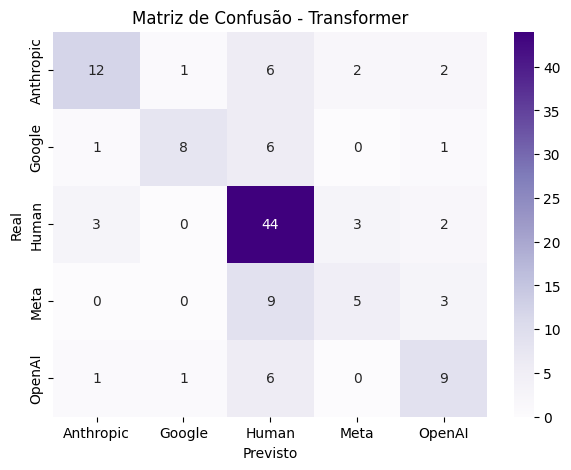

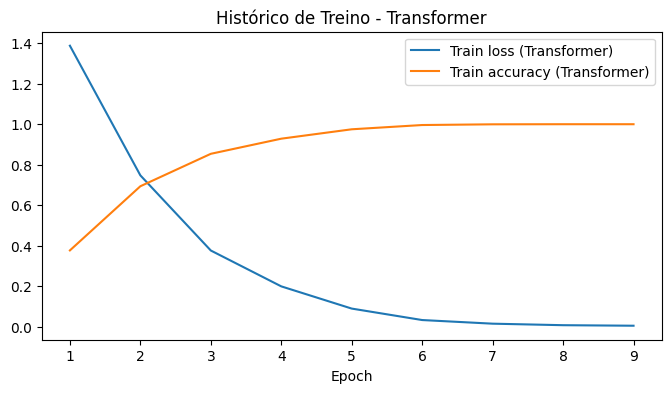

In [42]:
val_preds_tr  = np.array([labels[i] for i in np.argmax(val_probs_tr, axis=1)])
test_preds_tr = np.array([labels[i] for i in np.argmax(test_probs_tr, axis=1)])

tr_val_acc  = accuracy_score_np(y_val,   val_preds_tr)
tr_test_acc = accuracy_score_np(y_teste, test_preds_tr)

print(f'Validation accuracy: {tr_val_acc:.4f}')
print(f'Test accuracy:       {tr_test_acc:.4f}')
print('\nClassification report (teste) - Transformer:')
print(classification_report_np(y_teste, test_preds_tr, labels))

cm_tr = confusion_matrix_np(y_teste, test_preds_tr, labels)
cm_tr_df = pd.DataFrame(cm_tr, index=labels, columns=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_tr_df, annot=True, fmt='d', cmap='Purples')
plt.title('Matriz de Confusão - Transformer')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

history_tr_df = pd.DataFrame.from_dict(transformer.history, orient='index')
plt.figure(figsize=(8, 4))
plt.plot(history_tr_df.index, history_tr_df['loss'], label='Train loss (Transformer)')
plt.plot(history_tr_df.index, history_tr_df['acc'],  label='Train accuracy (Transformer)')
plt.title('Histórico de Treino - Transformer')
plt.xlabel('Epoch')
plt.legend()
plt.show()


## Comparação Final: Baseline vs Transformer


Resumo comparativo:


,Model,Val Accuracy,Test Accuracy
0,Baseline LogReg,0.847,0.568
1,Transformer,0.819,0.624


<Figure size 600x400 with 0 Axes>

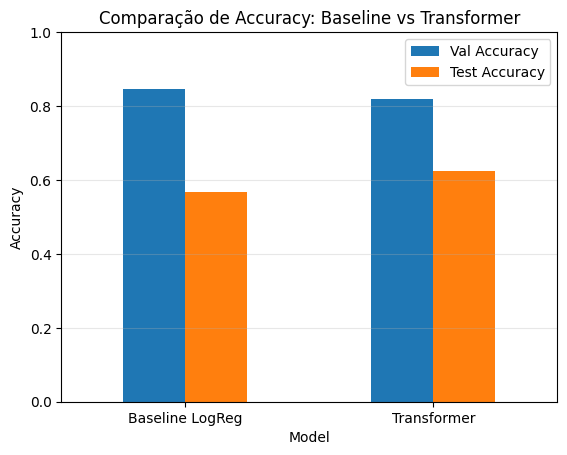

In [43]:
comparison_df = pd.DataFrame(
    [
        {
            'Model': 'Baseline LogReg',
            'Val Accuracy':  base_val_acc,
            'Test Accuracy': base_test_acc,
        },
        {
            'Model': 'Transformer',
            'Val Accuracy':  tr_val_acc,
            'Test Accuracy': tr_test_acc,
        },
    ]
)

comparison_df[['Val Accuracy', 'Test Accuracy']] = comparison_df[['Val Accuracy', 'Test Accuracy']].round(4)

print('Resumo comparativo:')
display(comparison_df)

plt.figure(figsize=(6, 4))
plot_df = comparison_df.set_index('Model')[['Val Accuracy', 'Test Accuracy']]
plot_df.plot(kind='bar', rot=0)
plt.title('Comparação de Accuracy: Baseline vs Transformer')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.show()
